In [247]:
from pathlib import Path

import pandas as pd
import sys
sys.path.insert(0, '.')
from lib.classes.Satellite import Satellite, InstantSatellite
from lib.classes.Point import Point
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from lib.classes.Satellite import EMISSION_RANGES

def load_data(filepath: str | Path, separator: str = ",", header: int | None = None) -> pd.DataFrame:
    """Load raw data from a CSV file.

    Args:
        filepath: Path to the CSV file (str or Path object).
        separator: Column delimiter used in the CSV file. Defaults to ','.
        header: Row number to use as column names.
                None means no header row. Defaults to None.

    Returns:
        Raw DataFrame loaded from the CSV file.

    Raises:
        FileNotFoundError: If the file does not exist at the given path.
        ValueError: If the file extension is not '.csv'.
    """
    filepath = Path(filepath)

    if not filepath.exists():
        raise FileNotFoundError(f"File not found: '{filepath}'")

    if filepath.suffix.lower() != ".csv":
        raise ValueError(
            f"Expected a '.csv' file, got '{filepath.suffix}' instead."
        )

    return pd.read_csv(filepath, sep=separator, header=header)

def struct_data(df: pd.DataFrame) -> list[Satellite]:
    import time

    # Create columns label
    df.columns = [f"t{i}" for i in range(len(df.columns))]

    satellites = []
    start = time.perf_counter()

    # Satellite coordinate data processing
    for i in range(0, len(df), 3):
        coords = df.iloc[i:i+3].values
        sat_id = int(i/3)
        satellite = Satellite(sat_id, f"SAT-{sat_id:03d}")

        for j in range(coords.shape[1]):
            satellite.add_instant(Point(coords[0, j], coords[1, j], coords[2, j]))

        satellites.append(satellite)

    # Satellite neighbors processing — cumulative neighbors at each emission range
    for index, sat in enumerate(satellites):
        for other_sat in satellites[index+1:]:
            for i in range(len(sat.list_coordinates)):
                p1 = sat.list_coordinates[i].point
                p2 = other_sat.list_coordinates[i].point
                for r in EMISSION_RANGES:
                    if p1.in_range(p2, r):
                        sat.list_coordinates[i].add_neighbor(other_sat, r)
                        other_sat.list_coordinates[i].add_neighbor(sat, r)

    end = time.perf_counter()
    print(len(satellites))
    print(f"Temps ecoulé : {end - start:.2f} secondes")

    return satellites

def show_data(satellites: list[Satellite], number: int) -> None:
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    for sat in satellites[:number]:
        xs = np.array([instant.point.x for instant in sat.list_coordinates])
        ys = np.array([instant.point.y for instant in sat.list_coordinates])
        zs = np.array([instant.point.z for instant in sat.list_coordinates])

        axes.plot(xs, ys, zs, label=f"Sat {sat.name}")

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title("Trajectoires des Satellites")
    plt.show()


def show_instant_nodes(satellites: list[Satellite], instant: int) -> None:
    plt.show()
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    # Create Nodes
    for sat in satellites:
        point = sat.list_coordinates[instant].point    
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            c='blue',
            label='Satellites')

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()

def show_instant_nodes_edges(satellites: list[Satellite], instant: int) -> None:
    plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")

    # Create Nodes and edges
    for sat in satellites:
        # Nodes
        point = sat.list_coordinates[instant].point    
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            #c='blue',
            label='Satellites')

        # Edges
        for neighbor in sat.list_coordinates[instant].neighbors:
            neighbor_point = neighbor.list_coordinates[instant].point
            axes.plot(
                [point.x, neighbor_point.x],
                [point.y, neighbor_point.y],
                [point.z, neighbor_point.z],
                'r-',
                alpha=0.1,
                linewidth=1
            )


    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()

def show_instant_nodes_neighbor(satellites: list[Satellite], instant: int, label: bool = True) -> None:
    fig = plt.figure(figsize=(15, 15))
    axes = plt.axes(projection="3d")


    densities = np.array([
        len(sat.list_coordinates[instant].neighbors)
        for sat in satellites
    ])

    norm = plt.Normalize(vmin=densities.min(), vmax=densities.max())
    colormap = cm.viridis

    # Create Nodes and edges
    for sat, density in zip(satellites, densities):
        # Nodes
        color = (255/255, 0/255, 0/255, 1.0) if density == 0 else colormap(norm(density)) 
        point = sat.list_coordinates[instant].point
        axes.scatter(
            xs=point.x,
            ys=point.y,
            zs=point.z,
            s=50,
            color=color,
            label='Satellites')
        
        if label:
            axes.text(
                x=point.x,
                y=point.y,
                z=point.z,
                s=sat.name,
                fontsize=8,
                color='black',
                ha='right',
                va='bottom')

        # Edges
        for neighbor in sat.list_coordinates[instant].neighbors:
            neighbor_point = neighbor.list_coordinates[instant].point
            axes.plot(
                [point.x, neighbor_point.x],
                [point.y, neighbor_point.y],
                [point.z, neighbor_point.z],
                'r-',
                alpha=0.1,
                linewidth=1
            )

    scalar_mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
    scalar_mappable.set_array(densities)
    fig.colorbar(scalar_mappable, ax=axes, label="Nombre de voisins", shrink=0.5)

    axes.set_xlabel('X')
    axes.set_ylabel('Y')
    axes.set_zlabel('Z')
    axes.set_title(f"t{instant} des Satellites")
    # plt.legend()
    plt.show()


In [185]:
data = load_data("./traces.csv")
print(data[:10])
satellites = struct_data(data)

           0             1             2             3             4     \
0 -4.850747e+05 -4.937755e+05 -5.024536e+05 -5.111086e+05 -5.197401e+05   
1 -7.066530e+05 -7.201117e+05 -7.335372e+05 -7.469290e+05 -7.602864e+05   
2 -2.026363e+06 -2.019625e+06 -2.012795e+06 -2.005871e+06 -1.998855e+06   
3 -4.167305e+05 -4.253905e+05 -4.340304e+05 -4.426496e+05 -4.512477e+05   
4 -7.114496e+05 -7.251144e+05 -7.387446e+05 -7.523398e+05 -7.658991e+05   
5 -2.013985e+06 -2.007244e+06 -2.000408e+06 -1.993476e+06 -1.986450e+06   
6 -4.839084e+05 -4.922692e+05 -5.006077e+05 -5.089237e+05 -5.172168e+05   
7 -7.608448e+05 -7.742544e+05 -7.876291e+05 -8.009682e+05 -8.142713e+05   
8 -2.023770e+06 -2.016739e+06 -2.009618e+06 -2.002406e+06 -1.995103e+06   
9 -3.527034e+05 -3.616050e+05 -3.704891e+05 -3.793552e+05 -3.882029e+05   

           5             6             7             8             9     ...  \
0 -5.283476e+05 -5.369309e+05 -5.454894e+05 -5.540229e+05 -5.625310e+05  ...   
1 -7.736088e+0

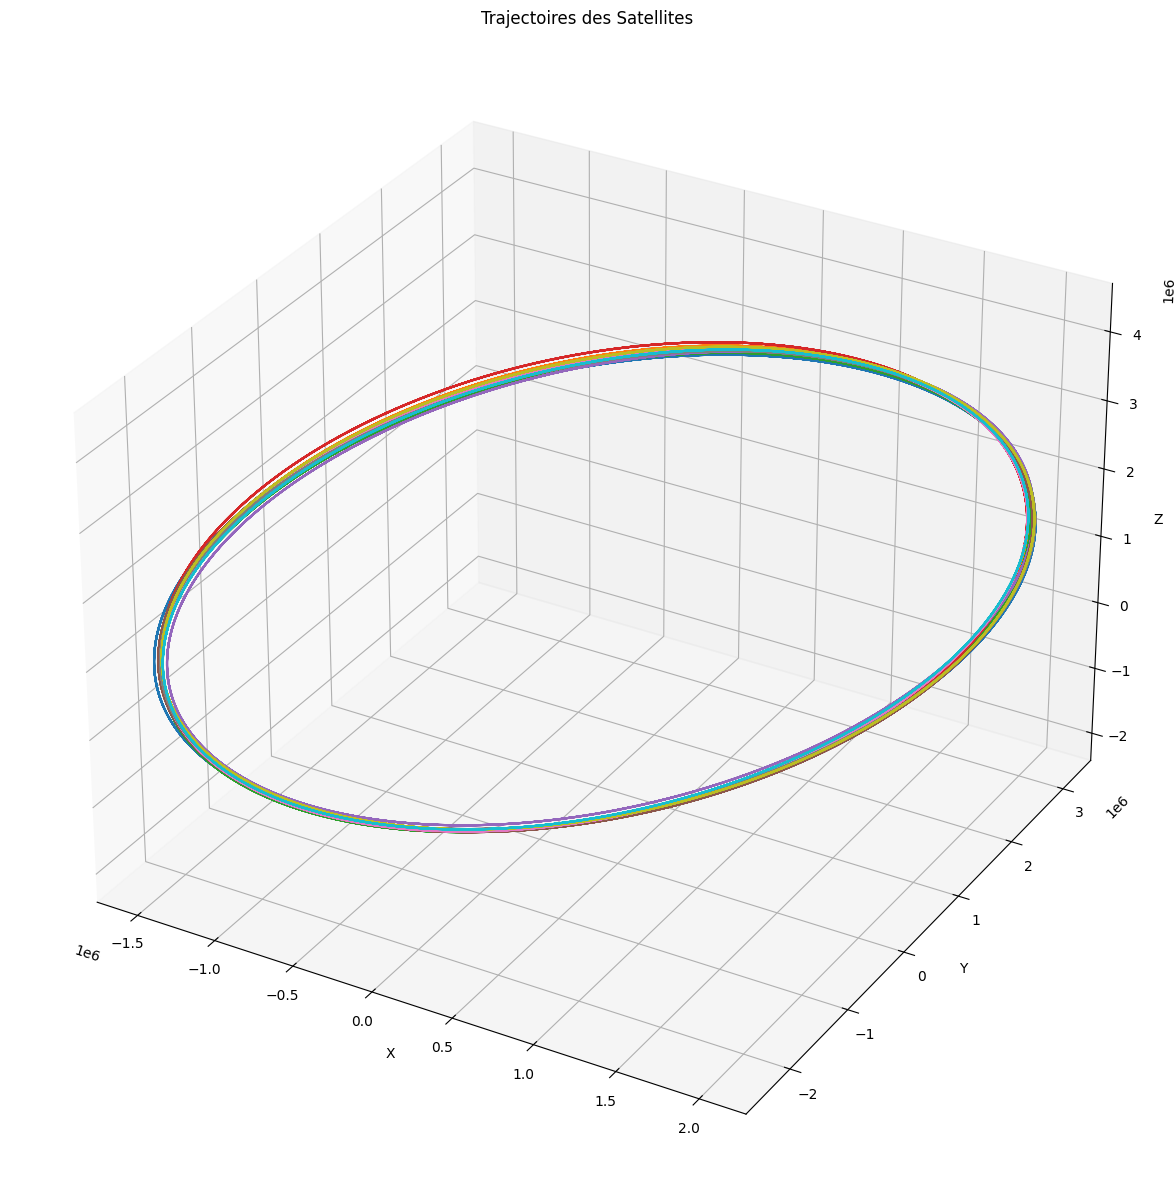

In [248]:
show_data(satellites, 10)

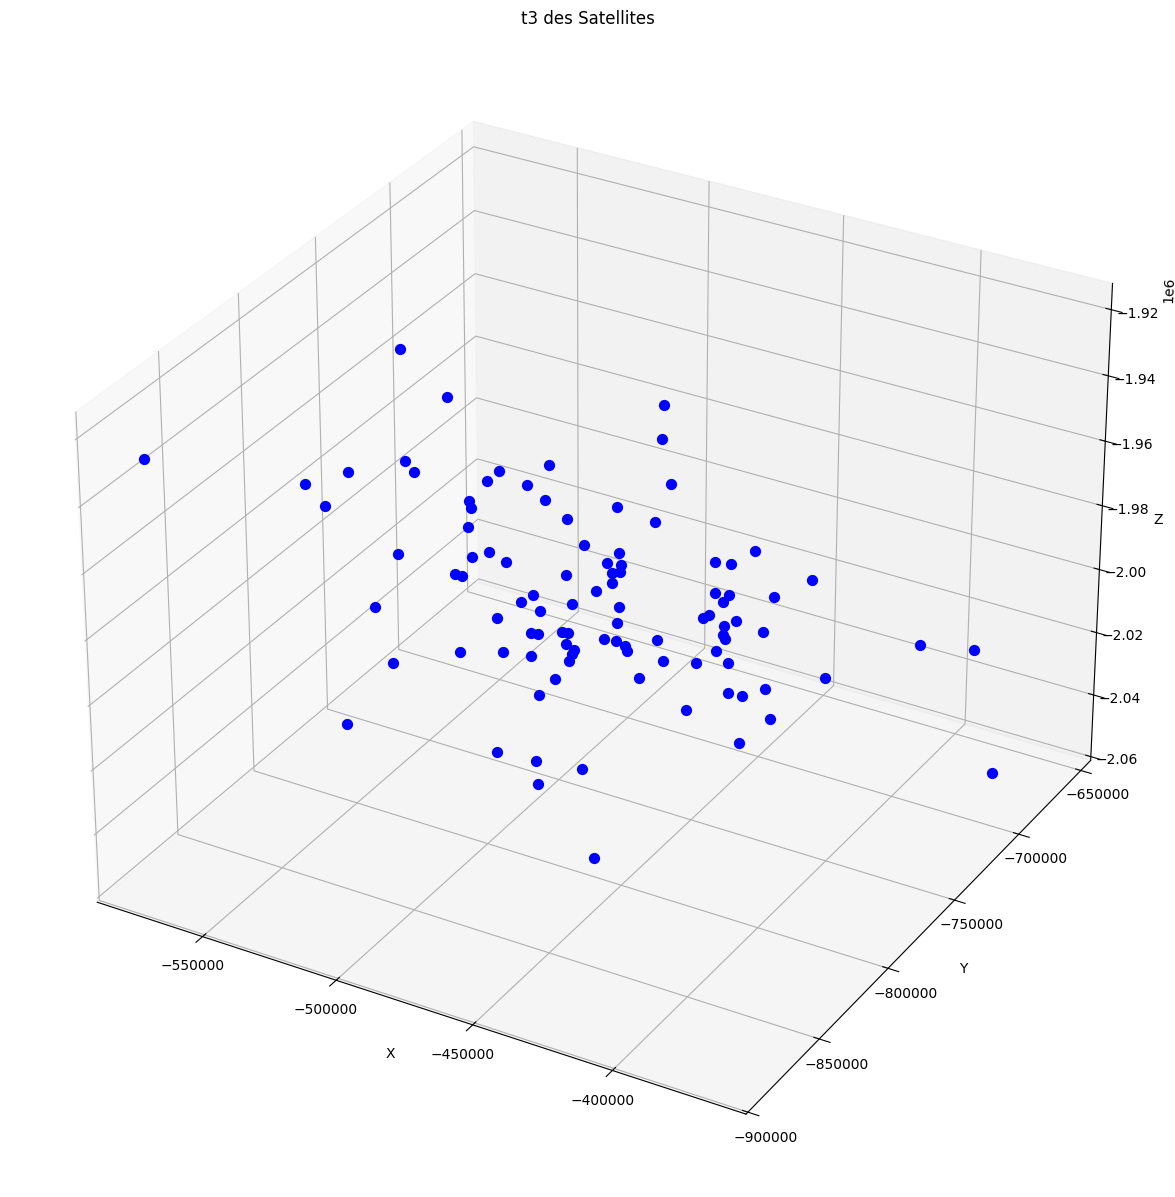

In [187]:
show_instant_nodes(satellites, 3)

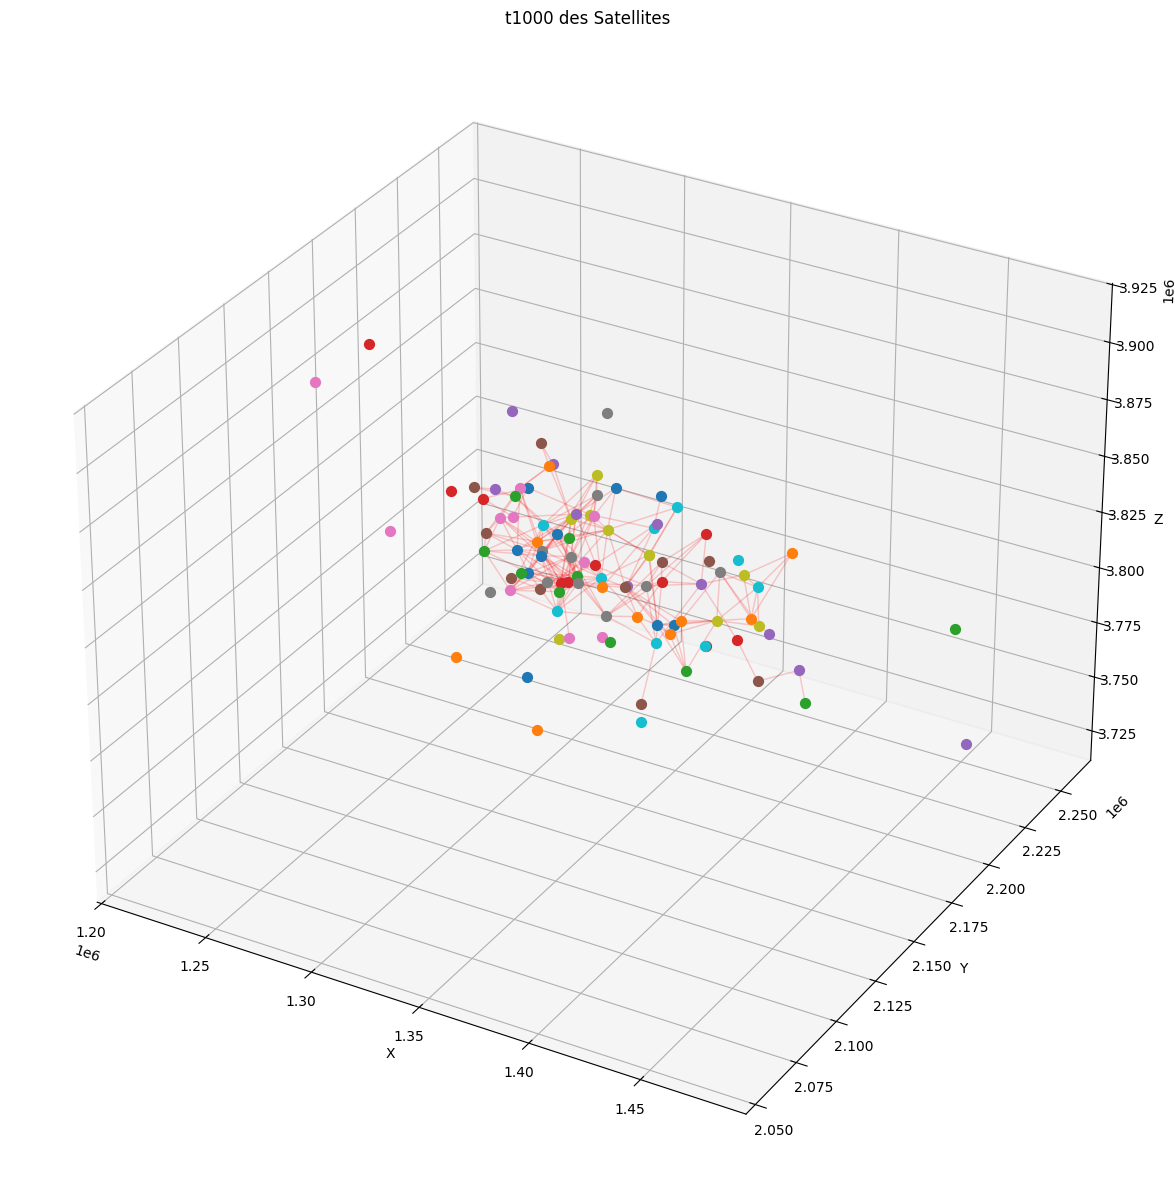

In [188]:
show_instant_nodes_edges(satellites, 1000)

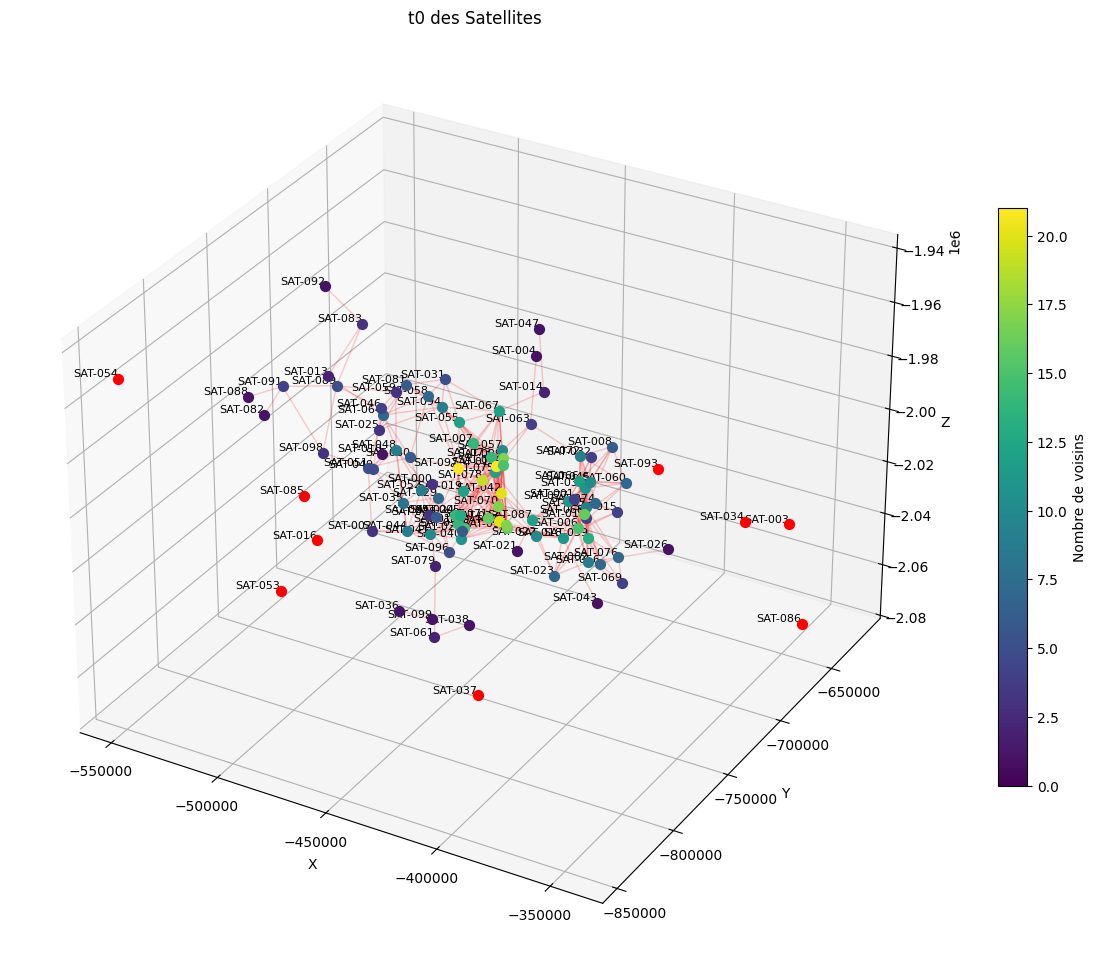

In [189]:
show_instant_nodes_neighbor(satellites=satellites, instant=0, label=True)


In [190]:
from lib.classes.NetworkSimulation import NetworkSimulation, PDU, FloodingRouter

list_satellites = satellites 
nb_instants = len(satellites[0].list_coordinates)

# Tuple description
# (Instant index of PDU, PDU)
example_scenario = [
    (0, PDU(1, list_satellites[0].name, list_satellites[-1].name)),
    (1, PDU(2, list_satellites[0].name, list_satellites[-1].name)),
    (2, PDU(3, list_satellites[0].name, list_satellites[-1].name)),
]

simulation = NetworkSimulation(satellites, FloodingRouter, example_scenario)
print(f"At time {simulation.current_index}, does {list_satellites[0].name} have messages to send ? {simulation.routers[list_satellites[0].name].any_messages_to_send()}")
simulation.next()
print(f"At time {simulation.current_index}, does {list_satellites[0].name} have messages to send ? {simulation.routers[list_satellites[0].name].any_messages_to_send()}")

def messages_received_of_dest():
    return simulation.routers[list_satellites[-1].name].pdus_where_this_router_is_the_destination

while len(messages_received_of_dest()) < len(example_scenario) and simulation.current_index < nb_instants:
    simulation.next()

print(f"At time {simulation.current_index}, {list_satellites[-1].name} has fully received {len(messages_received_of_dest())} messages")

if messages_received_of_dest():
    print("Traces of each messages")
    for pdu in messages_received_of_dest():
        print(pdu)

At time 0, does SAT-000 have messages to send ? False
At time 1, does SAT-000 have messages to send ? True
At time 10000, SAT-099 has fully received 0 messages


In [191]:
def count_unique_edges(sats, i):
    edge_set = set()
    for sat in sats:
        for neighbor in sat.list_coordinates[i].neighbors:
            lower, upper = (sat.name, neighbor.name) if sat.name < neighbor.name else (neighbor.name, sat.name)
            edge_set.add(f"{lower}-{upper}")
    return len(edge_set)
ue = count_unique_edges(satellites, 0)
ue

369

In [192]:
def degree_distribution(sats, i):
    distribution = {}
    for sat in sats:
        deg = len(sat.list_coordinates[i].neighbors)
        if deg in distribution:
            distribution[deg] += 1
        else:
            distribution[deg] = 1
    return dict(sorted(distribution.items()))
d = degree_distribution(satellites, 0)
print(sum(d.values()))
d

100


{0: 9,
 1: 12,
 2: 4,
 3: 7,
 4: 8,
 5: 5,
 6: 5,
 7: 8,
 8: 1,
 9: 7,
 10: 4,
 11: 4,
 12: 6,
 13: 2,
 14: 4,
 15: 3,
 16: 3,
 17: 3,
 19: 1,
 20: 2,
 21: 2}

In [193]:
def average_degree(sats, i, distribution_i = None):
    distrib = distribution_i if distribution_i is not None else degree_distribution(sats, i)
    return sum([deg * nb_sat for deg, nb_sat in distrib.items()]) / sum(distrib.values())
average_degree(satellites, 0, d) # d a déjà été défini avant

7.38

In [194]:
def max_edges_possible(sats):
    n = len(sats)
    return n*(n-1)/2
max_edges_possible(satellites)

4950.0

In [195]:
def density(sats, i, nb_unique_edges = None, max_edges = None):
    nb_l = nb_unique_edges if nb_unique_edges is not None else count_unique_edges(sats, i)
    max_l = max_edges if max_edges is not None else max_edges_possible(sats)
    return nb_l / max_l
density(satellites, 0, ue)

0.07454545454545454

In [196]:
def adjacency_matrix(sats, i):
    names = [sat.name for sat in sats]
    matrix = pd.DataFrame(0, index=names, columns=names)
    for sat in sats:
        for neighbor in sat.list_coordinates[i].neighbors:
            matrix.loc[sat.name, neighbor.name] = 1
    return matrix
adjacency_matrix(satellites, 0)

,SAT-000,SAT-001,SAT-002,SAT-003,SAT-004,SAT-005,SAT-006,SAT-007,SAT-008,SAT-009,...,SAT-090,SAT-091,SAT-092,SAT-093,SAT-094,SAT-095,SAT-096,SAT-097,SAT-098,SAT-099
SAT-000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
SAT-001,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAT-095,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-097,0,0,0,0,0,1,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0
SAT-098,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [197]:
def weight_matrix(sats, i):
    names = [sat.name for sat in sats]
    matrix = pd.DataFrame(0, index=names, columns=names)
    for sat in sats:
        for neighbor in sat.list_coordinates[i].neighbors:
            matrix.loc[sat.name, neighbor.name] = 10
    return matrix
weight_matrix(satellites, 0)

,SAT-000,SAT-001,SAT-002,SAT-003,SAT-004,SAT-005,SAT-006,SAT-007,SAT-008,SAT-009,...,SAT-090,SAT-091,SAT-092,SAT-093,SAT-094,SAT-095,SAT-096,SAT-097,SAT-098,SAT-099
SAT-000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,10,0,0,0,0
SAT-001,0,0,0,0,0,0,10,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAT-095,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SAT-097,0,0,0,0,0,10,0,10,0,10,...,0,0,0,0,10,0,0,0,0,0
SAT-098,0,0,0,0,0,0,0,0,0,0,...,0,10,0,0,0,0,0,0,0,0


In [198]:
def dijkstra(sats, i, start_sat_name, weight_mat = None):
    sats_dict = {sat.name: sat for sat in sats}
    w_matrix = weight_mat if weight_mat is not None else weight_matrix(sats, i)
    
    distances = {sat.name: [float('inf'), 0] for sat in sats}
    distances[start_sat_name] = [0, 1]

    candidates = [sat_name for sat_name in distances.keys()]

    while candidates:
        candidate = min(candidates, key=lambda x: distances[x][0])
        candidates.remove(candidate)
        
        sat = sats_dict[candidate]
        dist_sat, nb_best_paths_sat = distances[sat.name]

        if dist_sat == float('inf'):
            break;

        for neighbor in sat.list_coordinates[i].neighbors:
            dist_to_reach_neighbor = dist_sat + w_matrix.loc[sat.name, neighbor.name]
            if dist_to_reach_neighbor < distances[neighbor.name][0]:
                distances[neighbor.name][0] = dist_to_reach_neighbor
                distances[neighbor.name][1] = nb_best_paths_sat
            elif dist_to_reach_neighbor < distances[neighbor.name][0]:
                distances[neighbor.name][1] += nb_best_paths_sat
                
    return distances

dijkstra(satellites, 0, satellites[0].name)

{'SAT-000': [0, 1],
 'SAT-001': [np.int64(40), 1],
 'SAT-002': [np.int64(40), 1],
 'SAT-003': [inf, 0],
 'SAT-004': [np.int64(30), 1],
 'SAT-005': [np.int64(30), 1],
 'SAT-006': [np.int64(30), 1],
 'SAT-007': [np.int64(20), 1],
 'SAT-008': [np.int64(40), 1],
 'SAT-009': [np.int64(20), 1],
 'SAT-010': [np.int64(70), 1],
 'SAT-011': [np.int64(30), 1],
 'SAT-012': [np.int64(40), 1],
 'SAT-013': [np.int64(50), 1],
 'SAT-014': [np.int64(40), 1],
 'SAT-015': [np.int64(40), 1],
 'SAT-016': [inf, 0],
 'SAT-017': [np.int64(20), 1],
 'SAT-018': [np.int64(30), 1],
 'SAT-019': [np.int64(10), 1],
 'SAT-020': [np.int64(50), 1],
 'SAT-021': [np.int64(30), 1],
 'SAT-022': [np.int64(30), 1],
 'SAT-023': [np.int64(30), 1],
 'SAT-024': [np.int64(30), 1],
 'SAT-025': [np.int64(40), 1],
 'SAT-026': [np.int64(50), 1],
 'SAT-027': [np.int64(30), 1],
 'SAT-028': [np.int64(50), 1],
 'SAT-029': [np.int64(50), 1],
 'SAT-030': [np.int64(30), 1],
 'SAT-031': [np.int64(40), 1],
 'SAT-032': [np.int64(40), 1],
 'SAT-

In [199]:
def count_unreachable_satellites(sats, i):
    return [len(sat.list_coordinates[i].neighbors) for sat in sats].count(0)
count_unreachable_satellites(satellites, 0)

9

In [200]:
def betweeness_centrality(sats, i, sat_one_name, weight_mat = None, all_dijkstras = None):
    w_matrix = weight_mat if weight_mat is not None else weight_matrix(sats, i)
    sat_one = next((sat for sat in sats if sat.name == sat_one_name), None)
    
    dijkstras = all_dijkstras if all_dijkstras is not None else {sat.name: dijkstra(sats, i, sat.name, w_matrix) for sat in sats}

    res = []
    for sat_two in sats:
        if sat_two.name != sat_one_name:
            weight_two_to_one, nb_best_paths_between_two_to_one = dijkstras[sat_two.name][sat_one.name]

            for sat_three in sats:
                if sat_three.name != sat_one_name and sat_three.name != sat_two.name:
                    weight_three_to_two, nb_best_paths_between_three_to_two = dijkstras[sat_three.name][sat_two.name]
                    weight_three_to_one, nb_best_paths_between_three_to_one = dijkstras[sat_three.name][sat_one.name]

                    if nb_best_paths_between_three_to_two == 0:
                        continue
                    
                    if (weight_two_to_one + weight_three_to_one) != weight_three_to_two:
                        nb_best_paths_between_two_to_three_passing_by_one = 0
                    else:
                        nb_best_paths_between_two_to_three_passing_by_one = nb_best_paths_between_two_to_one * nb_best_paths_between_three_to_one

                    res.append(nb_best_paths_between_two_to_three_passing_by_one / nb_best_paths_between_three_to_two)
    
    return sum(res)

betweeness_centrality(satellites, 0, satellites[0].name)

192.0

In [201]:
i = 0
w_matrix = weight_matrix(satellites, i)
dijkstras = {sat.name: dijkstra(satellites, i, sat.name, w_matrix) for sat in satellites}

bcs = {sat.name: betweeness_centrality(satellites, i, sat.name, w_matrix, dijkstras) for sat in satellites}
bcs

{'SAT-000': 192.0,
 'SAT-001': 0.0,
 'SAT-002': 58.0,
 'SAT-003': 0.0,
 'SAT-004': 0.0,
 'SAT-005': 518.0,
 'SAT-006': 790.0,
 'SAT-007': 1306.0,
 'SAT-008': 0.0,
 'SAT-009': 1070.0,
 'SAT-010': 0.0,
 'SAT-011': 810.0,
 'SAT-012': 4.0,
 'SAT-013': 480.0,
 'SAT-014': 174.0,
 'SAT-015': 0.0,
 'SAT-016': 0.0,
 'SAT-017': 1250.0,
 'SAT-018': 1674.0,
 'SAT-019': 912.0,
 'SAT-020': 18.0,
 'SAT-021': 0.0,
 'SAT-022': 1242.0,
 'SAT-023': 202.0,
 'SAT-024': 782.0,
 'SAT-025': 0.0,
 'SAT-026': 0.0,
 'SAT-027': 1570.0,
 'SAT-028': 18.0,
 'SAT-029': 54.0,
 'SAT-030': 598.0,
 'SAT-031': 34.0,
 'SAT-032': 18.0,
 'SAT-033': 2276.0,
 'SAT-034': 0.0,
 'SAT-035': 318.0,
 'SAT-036': 0.0,
 'SAT-037': 0.0,
 'SAT-038': 0.0,
 'SAT-039': 974.0,
 'SAT-040': 454.0,
 'SAT-041': 1290.0,
 'SAT-042': 2918.0,
 'SAT-043': 0.0,
 'SAT-044': 1000.0,
 'SAT-045': 90.0,
 'SAT-046': 616.0,
 'SAT-047': 0.0,
 'SAT-048': 1576.0,
 'SAT-049': 800.0,
 'SAT-050': 1182.0,
 'SAT-051': 182.0,
 'SAT-052': 948.0,
 'SAT-053': 0.0,
 'SAT

In [202]:
# Choisissez le satellite source et le satellite destination
# (utilisez le graphe avec labels ci-dessus pour identifier les satellites)
SOURCE_NAME = "SAT-000"
DEST_NAME   = "SAT-088"

## Epidemic Routing simulation

In [293]:
import sys
for _key in list(sys.modules.keys()):
    if _key == "lib" or _key.startswith("lib."):
        del sys.modules[_key]

from lib.classes.NetworkSimulation import NetworkSimulation, PDU, EpidemicRouter
import matplotlib
matplotlib.rcParams["animation.embed_limit"] = 200
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import HTML
import numpy as np

MAX_STEPS = 200
FRAME_STRIDE = 1

source_sat = next(s for s in satellites if s.name == SOURCE_NAME)
dest_sat   = next(s for s in satellites if s.name == DEST_NAME)

pdu = PDU(1, source_sat.name, dest_sat.name)
sim = NetworkSimulation(satellites, EpidemicRouter, [(0, pdu)])

states = []
delivered_t = None

for t in range(MAX_STEPS):
    carriers = {
        name
        for name, router in sim.routers.items()
        if any(p.id == 1 for p in
               router.pdus_memory + router.pdus_to_send + router.receiving)
    }
    delivered = any(
        p.id == 1
        for p in sim.routers[dest_sat.name].pdus_where_this_router_is_the_destination
    )
    states.append({"t": t, "carriers": carriers, "delivered": delivered})
    if delivered and delivered_t is None:
        delivered_t = t
    sim.next()

end_frame = min((delivered_t or MAX_STEPS) + 15, MAX_STEPS)
states = states[:end_frame]
frames_to_show = list(range(0, len(states), FRAME_STRIDE))

n_final_carriers = len(states[-1]["carriers"])
print(f"Source : {source_sat.name} -> Destination : {dest_sat.name}")
print(f"Arrivee t = {delivered_t} | Porteurs finaux : {n_final_carriers} / {len(satellites)}")
print(f"Frames animees : {len(frames_to_show)} (stride={FRAME_STRIDE}, jusqu a t={end_frame})")

colormap = cm.viridis
fig = plt.figure(figsize=(10, 10), dpi=72)
axes = fig.add_subplot(111, projection="3d")

def animate(frame_idx):
    axes.cla()
    i = frames_to_show[frame_idx]
    state = states[i]

    densities = np.array([
        len(list(sat.list_coordinates[i].neighbors))
        for sat in satellites
    ])
    norm = plt.Normalize(vmin=densities.min(), vmax=densities.max())

    for sat, density in zip(satellites, densities):
        pt = sat.list_coordinates[i].point

        if sat.name == dest_sat.name and state["delivered"]:
            color = (0.0, 0.85, 0.0, 1.0)
        elif sat.name == dest_sat.name:
            color = (1.0, 0.55, 0.0, 1.0)
        elif sat.name == source_sat.name:
            color = (0.2, 0.4, 1.0, 1.0)
        elif sat.name in state["carriers"]:
            color = (1.0, 0.95, 0.0, 1.0)
        elif density == 0:
            color = (1.0, 0.0, 0.0, 1.0)
        else:
            color = colormap(norm(density))

        axes.scatter(xs=pt.x, ys=pt.y, zs=pt.z, s=50, color=color)

        for neighbor in sat.list_coordinates[i].neighbors:
            np_pt = neighbor.list_coordinates[i].point
            axes.plot(
                [pt.x, np_pt.x],
                [pt.y, np_pt.y],
                [pt.z, np_pt.z],
                "r-", alpha=0.1, linewidth=1
            )

    axes.set_xlabel("X")
    axes.set_ylabel("Y")
    axes.set_zlabel("Z")
    n = len(state["carriers"])
    status = f"LIVRE a t={delivered_t}" if state["delivered"] else f"Porteurs : {n}/{len(satellites)}"
    axes.set_title(f"Epidemic Routing | t={i} | {status}")
    axes.view_init(elev=25, azim=45)

anim = FuncAnimation(fig, animate, frames=len(frames_to_show), interval=120, repeat=False)
plt.close()
HTML(anim.to_jshtml())


Source : SAT-000 -> Destination : SAT-088
Arrivee t = 10 | Porteurs finaux : 89 / 100
Frames animees : 25 (stride=1, jusqu a t=25)


### Epidemic routing performance value

In [294]:
import sys
for _key in list(sys.modules.keys()):
    if _key == "lib" or _key.startswith("lib."):
        del sys.modules[_key]

from lib.utils.metrics import run_epidemic_metrics, print_metrics_report, MetricsConfig

# Parametres physiques (step_duration calibre depuis traces.csv)
#   periode orbitale ~ 1792 pas, LEO 500km -> T ~ 94.6 min -> 1 pas ~ 3.2 s
config = MetricsConfig(
    step_duration_s = 3.2,    # s/pas (ajustable)
    link_rate_bps   = 1_000_000,  # UHF CubeSat typique
    pdu_size_bytes  = 1_000,  # 1 KB par bundle
)

metrics = run_epidemic_metrics(
    satellites          = satellites,
    source_name         = SOURCE_NAME,
    dest_name           = DEST_NAME,
    n_pdus              = 8,
    injection_interval  = 20,   # injecte 1 PDU toutes les 20 etapes
    config              = config,
    max_steps           = 500,
)

print_metrics_report(metrics)


  METRIQUES EPIDEMIC ROUTING -- bout en bout
  Duree d'un pas     : 3.2 s
  Debit du lien      : 1000.0 kbps
  Taille PDU         : 1000 B
  Tx par hop         : 0.008 s
  PDU max valide     : 400000 B  (OK)

  Duree simulation   : 26.7 min
  PDUs envoyes       : 8
  PDUs recus         : 8
  Taux de livraison  : 100.0 %
  Goodput            : 40.00 bps  (0.00 % du debit lien)

  Latence moyenne    : 3.3 s  +/- 0.0 s
  Latence min/max    : 3.3 / 3.3 s
    dont stockage    : 3.2 s  (98.0 %)
    dont tx          : 0.1 s  (2.0 %)
    dont prop.       : 0.636 ms  (0.0 %)
  Sauts moyens       : 8.2

   ID   Inj.   Livr.       Latence  Hops  Trace
  ----------------------------------------------------------
    0      0      10        3.3 s     9  SAT-000 -> SAT-019 -> SAT-007 -> SAT-097 -> SAT-080 -> SAT-048 -> SAT-046 -> SAT-089 -> SAT-091 -> SAT-088
    1     20      29        3.3 s     8  SAT-000 -> SAT-019 -> SAT-007 -> SAT-094 -> SAT-064 -> SAT-013 -> SAT-089 -> SAT-091 -> SAT-088
    2

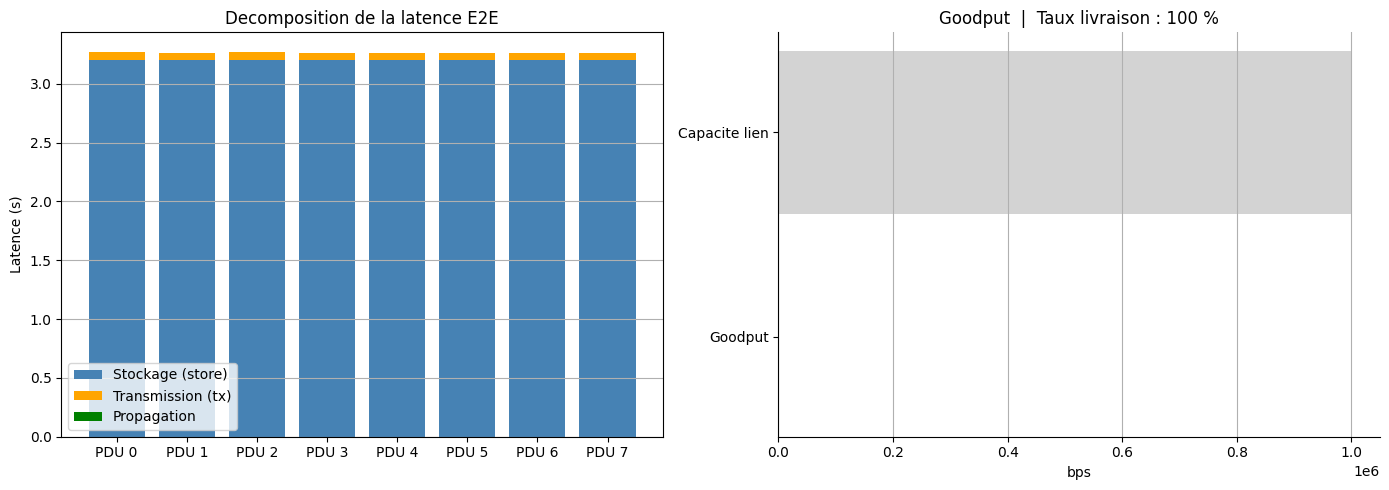

In [295]:
import matplotlib.pyplot as plt
import numpy as np

ok = [r for r in metrics["results"] if r.delivered]
if not ok:
    print("Aucun PDU livre.")
else:
    ids           = [r.pdu_id        for r in ok]
    latencies_s   = [r.latency_s     for r in ok]
    store_s       = [r.store_delay_s for r in ok]
    tx_s          = [r.tx_delay_s    for r in ok]
    prop_ms       = [r.prop_delay_s * 1000 for r in ok]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -- Decomposition de la latence --
    ax = axes[0]
    x = np.arange(len(ok))
    ax.bar(x, store_s, label="Stockage (store)", color="steelblue")
    ax.bar(x, tx_s,    bottom=store_s, label="Transmission (tx)", color="orange")
    ax.bar(x, [p/1000 for p in prop_ms], bottom=[s+t for s,t in zip(store_s,tx_s)],
           label="Propagation", color="green")
    ax.set_xticks(x); ax.set_xticklabels([f"PDU {i}" for i in ids])
    ax.set_ylabel("Latence (s)")
    ax.set_title("Decomposition de la latence E2E")
    ax.legend(); ax.grid(axis="y")

    # -- Goodput vs taux de livraison --
    ax = axes[1]
    cfg = metrics["config"]
    ax.barh(["Goodput"], [metrics["goodput_bps"]], color="steelblue")
    ax.barh(["Capacite lien"], [cfg.link_rate_bps], color="lightgray")
    ax.set_xlabel("bps")
    ax.set_title(f"Goodput  |  Taux livraison : {metrics["delivery_ratio"]*100:.0f} %")
    for spine in ["top","right"]: ax.spines[spine].set_visible(False)
    ax.grid(axis="x")

    plt.tight_layout()
    plt.show()


## Pannes de satellites

Simulation de coupures de satellites — **volontaires** (liste explicite), **aléatoires** (tirage), ou **mixtes** — avec comparaison des métriques avant / après panne.


In [296]:
import sys
for _key in list(sys.modules.keys()):
    if _key == "lib" or _key.startswith("lib."):
        del sys.modules[_key]

from lib.utils.failure import FailureConfig, run_failure_comparison, print_comparison_table, comparison_dataframe


### Panne volontaire — satellite(s) choisi(s) manuellement


In [297]:
# Configurez ici les satellites à mettre hors-service volontairement
# Astuce : choisir un satellite ayant une betweenness-centrality élevée
#          (cf. cellule betweenness ci-dessus) pour maximiser l'impact.
voluntary_config = FailureConfig(
    failed_satellite_names=["SAT-098", "SAT-089"],  # pivot observé sur la route SAT-000→SAT-088
    t_start=0,
    t_end=None,  # None = panne permanente sur toute la simulation
)

comp_voluntary = run_failure_comparison(
    satellites=satellites,
    source_name=SOURCE_NAME,
    dest_name=DEST_NAME,
    failure_config=voluntary_config,
    metrics_config=config,
    n_pdus=8,
    injection_interval=20,
    max_steps=1800,
)

print_comparison_table(comp_voluntary, SOURCE_NAME, DEST_NAME)


  COMPARAISON AVANT / APRES PANNES
  Source --> Dest      : SAT-000 --> SAT-088
  Satellites en panne  : SAT-098, SAT-089
  Type                 : volontaire
  Fenetre de panne     : pas 0 --> 9999
------------------------------------------------------------------------
  Metrique                            Avant      Apres      Delta
------------------------------------------------------------------------
  Taux de livraison (%)              100.00     100.00      +0.0%
  PDUs livres                          8.00       8.00      +0.0%
  Goodput (bps)                       11.11      11.11      +0.0%
  Latence moy. (s)                     3.27      16.07    +391.8%
  Latence min (s)                      3.26       3.26      +0.0%
  Latence max (s)                      3.27      86.46   +2542.0%
  Ecart-type lat. (s)                  0.00      27.34 +789853.1%
  Sauts moyens                         8.25       8.25      +0.0%
  Stockage moy. (s)                    3.20      16.00    +400

### Panne aléatoire — tirage automatique de satellites


In [298]:
random_config = FailureConfig(
    n_random_failures=25,          # nombre de satellites tirés au hasard
    random_seed=None,               # pour reproductibilité (None = non-déterministe)
    t_start=0,
    t_end=None,                        # None = panne permanente sur toute la simulation, 100 = panne de t=0 à t=100
    exclude_from_random=[SOURCE_NAME, DEST_NAME],  # source/dest jamais tirées
)

comp_random = run_failure_comparison(
    satellites=satellites,
    source_name=SOURCE_NAME,
    dest_name=DEST_NAME,
    failure_config=random_config,
    metrics_config=config,
    n_pdus=8,
    injection_interval=20,
    max_steps=1800,
)

print_comparison_table(comp_random, SOURCE_NAME, DEST_NAME)


  COMPARAISON AVANT / APRES PANNES
  Source --> Dest      : SAT-000 --> SAT-088
  Satellites en panne  : SAT-022, SAT-026, SAT-016, SAT-017, SAT-082, SAT-036, SAT-042, SAT-029, SAT-097, SAT-038, SAT-077, SAT-056, SAT-081, SAT-075, SAT-051, SAT-033, SAT-055, SAT-078, SAT-024, SAT-068, SAT-059, SAT-011, SAT-020, SAT-090, SAT-095
  Type                 : aleatoire
  Fenetre de panne     : pas 0 --> 9999
------------------------------------------------------------------------
  Metrique                            Avant      Apres      Delta
------------------------------------------------------------------------
  Taux de livraison (%)              100.00     100.00      +0.0%
  PDUs livres                          8.00       8.00      +0.0%
  Goodput (bps)                       11.11      11.11      +0.0%
  Latence moy. (s)                     3.27       3.27      +0.0%
  Latence min (s)                      3.26       3.26      -0.0%
  Latence max (s)                      3.27       3.27

### Panne mixte — volontaire + aléatoire sur une fenêtre temporelle


In [299]:
mixed_config = FailureConfig(
    failed_satellite_names=["SAT-098", "SAT-089"],   # panne volontaire
    n_random_failures=25,                  # + 25 tirées au hasard
    random_seed=None,
    t_start=50,                           # panne transitoire : pas 50 à 300
    t_end=300,
    exclude_from_random=[SOURCE_NAME, DEST_NAME],
)

comp_mixed = run_failure_comparison(
    satellites=satellites,
    source_name=SOURCE_NAME,
    dest_name=DEST_NAME,
    failure_config=mixed_config,
    metrics_config=config,
    n_pdus=8,
    injection_interval=20,
    max_steps=1800,
)

print_comparison_table(comp_mixed, SOURCE_NAME, DEST_NAME)


  COMPARAISON AVANT / APRES PANNES
  Source --> Dest      : SAT-000 --> SAT-088
  Satellites en panne  : SAT-098, SAT-089, SAT-043, SAT-062, SAT-011, SAT-047, SAT-077, SAT-079, SAT-057, SAT-029, SAT-069, SAT-054, SAT-083, SAT-039, SAT-033, SAT-080, SAT-074, SAT-041, SAT-038, SAT-018, SAT-008, SAT-030, SAT-099, SAT-031, SAT-028, SAT-042, SAT-019
  Type                 : volontaire + aleatoire
  Fenetre de panne     : pas 50 --> 300
------------------------------------------------------------------------
  Metrique                            Avant      Apres      Delta
------------------------------------------------------------------------
  Taux de livraison (%)              100.00     100.00      +0.0%
  PDUs livres                          8.00       8.00      +0.0%
  Goodput (bps)                       11.11      11.11      +0.0%
  Latence moy. (s)                     3.27       3.27      +0.1%
  Latence min (s)                      3.26       3.26      -0.0%
  Latence max (s)      

### Visualisation comparative — graphique multi-scénarios


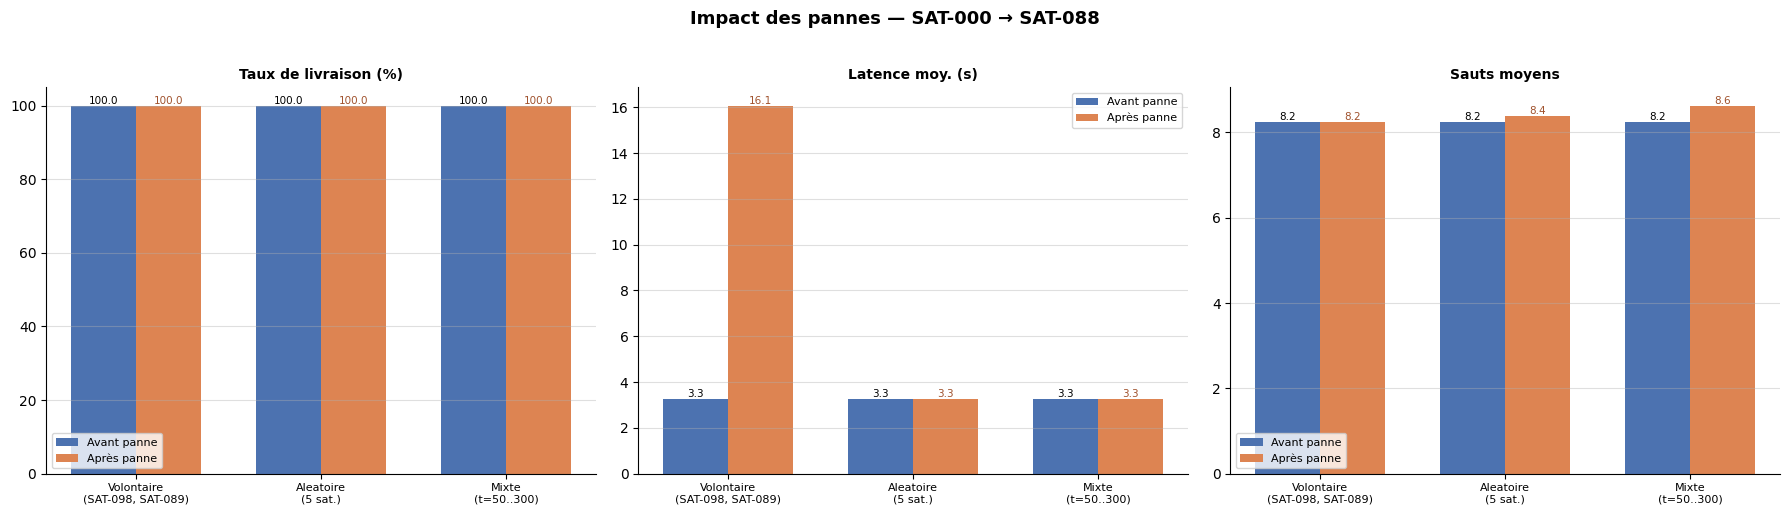

In [300]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Scénarios à comparer ---
scenarios = [
    ("Volontaire\n(SAT-098, SAT-089)", comp_voluntary),
    ("Aleatoire\n(5 sat.)",   comp_random),
    ("Mixte\n(t=50..300)",    comp_mixed),
]

# Métriques affichées et comment les extraire
metric_defs = [
    ("Taux de livraison (%)",  lambda m: m["delivery_ratio"] * 100),
    ("Latence moy. (s)",       lambda m: m.get("mean_latency_s") or 0),
    ("Sauts moyens",           lambda m: m.get("mean_hops") or 0),
]

fig, axes = plt.subplots(1, len(metric_defs), figsize=(18, 5))

x = np.arange(len(scenarios))
width = 0.35
color_before = "#4C72B0"
color_after  = "#DD8452"

for ax, (metric_label, getter) in zip(axes, metric_defs):
    vals_before = [getter(c["baseline"]) for _, c in scenarios]
    vals_after  = [getter(c["failure"])  for _, c in scenarios]

    bars_b = ax.bar(x - width / 2, vals_before, width, color=color_before, label="Avant panne")
    bars_f = ax.bar(x + width / 2, vals_after,  width, color=color_after,  label="Après panne")

    # Affiche la valeur au-dessus de chaque barre
    for bar in bars_b:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.1f}",
                ha="center", va="bottom", fontsize=7.5)
    for bar in bars_f:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.1f}",
                ha="center", va="bottom", fontsize=7.5, color="sienna")

    ax.set_title(metric_label, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([name for name, _ in scenarios], fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle(
    f"Impact des pannes — {SOURCE_NAME} → {DEST_NAME}",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()


---
## Comparaison Epidemic vs Link-State Routing

**Pertinence** : les satellites forment un réseau DTN (*Delay-Tolerant Network*) où la connectivité bout-en-bout est **intermittente**. Ces deux algorithmes représentent deux philosophies opposées :

| Algorithme | Copies | Stratégie | Avantage | Limite |
|---|---|---|---|---|
| **Epidemic** | Multi-copie (flood) | Store-carry-forward | Livraison garantie même sans chemin instantané | Surcharge réseau, latence élevée |
| **Link-State** | Copie unique | BFS plus court chemin à chaque pas | Latence minimale, zéro flood | Échec si aucun chemin n'existe à l'instant t |


### Rapport Link-State (conditions normales)


In [301]:
import sys
for _key in list(sys.modules.keys()):
    if _key == "lib" or _key.startswith("lib."):
        del sys.modules[_key]

from lib.utils.metrics import (
    run_linkstate_metrics, print_metrics_report,
    run_algo_comparison, print_algo_comparison_table, algo_comparison_dataframe,
    MetricsConfig,
)

ls_metrics = run_linkstate_metrics(
    satellites         = satellites,
    source_name        = SOURCE_NAME,
    dest_name          = DEST_NAME,
    n_pdus             = 8,
    injection_interval = 20,
    config             = config,
    max_steps          = 1800,
)

print_metrics_report(ls_metrics)


  METRIQUES EPIDEMIC ROUTING -- bout en bout
  Duree d'un pas     : 3.2 s
  Debit du lien      : 1000.0 kbps
  Taille PDU         : 1000 B
  Tx par hop         : 0.008 s
  PDU max valide     : 400000 B  (OK)

  Duree simulation   : 96.0 min
  PDUs envoyes       : 8
  PDUs recus         : 8
  Taux de livraison  : 100.0 %
  Goodput            : 11.11 bps  (0.00 % du debit lien)

  Latence moyenne    : 3.3 s  +/- 0.0 s
  Latence min/max    : 3.3 / 3.3 s
    dont stockage    : 3.2 s  (98.0 %)
    dont tx          : 0.1 s  (2.0 %)
    dont prop.       : 0.648 ms  (0.0 %)
  Sauts moyens       : 8.2

   ID   Inj.   Livr.       Latence  Hops  Trace
  ----------------------------------------------------------
    0      0      10        3.3 s     9  SAT-000 -> SAT-019 -> SAT-007 -> SAT-094 -> SAT-064 -> SAT-013 -> SAT-083 -> SAT-089 -> SAT-091 -> SAT-088
    1     20      29        3.3 s     8  SAT-000 -> SAT-019 -> SAT-007 -> SAT-094 -> SAT-064 -> SAT-013 -> SAT-089 -> SAT-091 -> SAT-088
    2

### Tableau comparatif — sans pannes


In [302]:
comp_algos_normal = run_algo_comparison(
    satellites         = satellites,
    source_name        = SOURCE_NAME,
    dest_name          = DEST_NAME,
    n_pdus             = 8,
    injection_interval = 20,
    config             = config,
    max_steps          = 500,
)

print_algo_comparison_table(comp_algos_normal, SOURCE_NAME, DEST_NAME)


  COMPARAISON ALGORITHMES : Epidemic vs Link-State Routing
  Source --> Dest : SAT-000 --> SAT-088
--------------------------------------------------------------------------------
  Metrique                           Epidemic   Link-State  Delta(LS/E)
--------------------------------------------------------------------------------
  Taux de livraison (%)                100.00       100.00        +0.0%
  PDUs livres                            8.00         8.00        +0.0%
  Goodput (bps)                         40.00        40.00        +0.0%
  Latence moy. (s)                       3.27         3.27        +0.0%
  Latence min (s)                        3.26         3.26        +0.0%
  Latence max (s)                        3.27         3.27        +0.0%
  Sauts moyens                           8.25         8.25        +0.0%
  Stockage moy. (s)                      3.20         3.20        +0.0%


### Tableau final — 2 algorithmes × avec/sans pannes (grand tableau)


In [303]:
# Utilise le scénario de panne volontaire (le plus impactant) pour le grand tableau
comp_algos_with_failure = run_algo_comparison(
    satellites         = satellites,
    source_name        = SOURCE_NAME,
    dest_name          = DEST_NAME,
    n_pdus             = 8,
    injection_interval = 20,
    config             = config,
    max_steps          = 1800,
    failure_config     = voluntary_config,   # réutilise la config de panne volontaire
)

print_algo_comparison_table(comp_algos_with_failure, SOURCE_NAME, DEST_NAME)


  COMPARAISON ALGORITHMES : Epidemic vs Link-State Routing
  Source --> Dest : SAT-000 --> SAT-088
  Pannes          : SAT-098, SAT-089
--------------------------------------------------------------------------------
  Metrique                    Ep.(norm)  LS (norm) Ep.(panne)  LS(panne)
--------------------------------------------------------------------------------
  Taux livraison (%)             100.00     100.00     100.00     100.00
  PDUs livres                      8.00       8.00       8.00       8.00
  Goodput (bps)                   11.11      11.11      11.11      11.11
  Latence moy. (s)                 3.27       3.27      16.07      28.47
  Latence min (s)                  3.26       3.26       3.26       3.26
  Latence max (s)                  3.27       3.27      86.46     134.48
  Sauts moyens                     8.25       8.25       8.25       8.75
  Stockage moy. (s)                3.20       3.20      16.00      28.40


## Pannes aléatoires en LSP

In [304]:
comp_algos_random_failure = run_algo_comparison(
    satellites         = satellites,
    source_name        = SOURCE_NAME,
    dest_name          = DEST_NAME,
    n_pdus             = 8,
    injection_interval = 20,
    config             = config,
    max_steps          = 1800,
    failure_config     = random_config,
)

print_algo_comparison_table(comp_algos_random_failure, SOURCE_NAME, DEST_NAME)

  COMPARAISON ALGORITHMES : Epidemic vs Link-State Routing
  Source --> Dest : SAT-000 --> SAT-088
  Pannes          : SAT-074, SAT-075, SAT-092, SAT-056, SAT-067, SAT-025, SAT-039, SAT-029, SAT-077, SAT-037, SAT-069, SAT-091, SAT-068, SAT-041, SAT-051, SAT-080, SAT-027, SAT-089, SAT-057, SAT-087, SAT-071, SAT-005, SAT-095, SAT-009, SAT-054
--------------------------------------------------------------------------------
  Metrique                    Ep.(norm)  LS (norm) Ep.(panne)  LS(panne)
--------------------------------------------------------------------------------
  Taux livraison (%)             100.00     100.00     100.00     100.00
  PDUs livres                      8.00       8.00       8.00       8.00
  Goodput (bps)                   11.11      11.11      11.11      11.11
  Latence moy. (s)                 3.27       3.27     268.47     291.26
  Latence min (s)                  3.26       3.26      44.86      67.26
  Latence max (s)                  3.27       3.27     49

### Visualisation finale — Epidemic vs Link-State × avec/sans pannes


TypeError: FigureBase.suptitle() takes 2 positional arguments but 3 were given

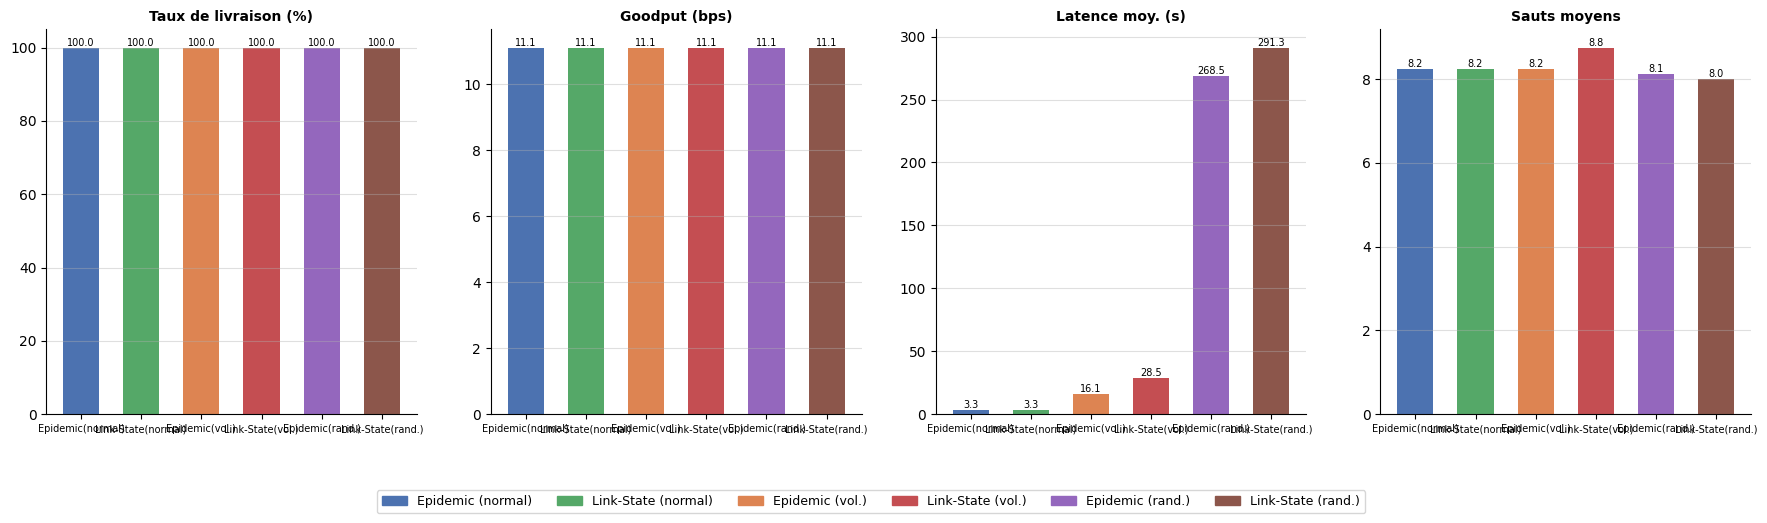

In [308]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ep_n   = comp_algos_with_failure['epidemic_normal']
ls_n   = comp_algos_with_failure['linkstate_normal']
ep_vol = comp_algos_with_failure['epidemic_failure']
ls_vol = comp_algos_with_failure['linkstate_failure']
ep_rnd = comp_algos_random_failure['epidemic_failure']
ls_rnd = comp_algos_random_failure['linkstate_failure']

metric_defs = [
    ("Taux de livraison (%)", lambda m: m["delivery_ratio"] * 100),
    ("Goodput (bps)",         lambda m: m["goodput_bps"]),
    ("Latence moy. (s)",      lambda m: m.get("mean_latency_s") or 0),
    ("Sauts moyens",          lambda m: m.get("mean_hops") or 0),
]

groups  = [
    "Epidemic(normal)", 
    "Link-State(normal)",
    "Epidemic(vol.)",   
    "Link-State(vol.)",
    "Epidemic(rand.)",  
    "Link-State(rand.)",
]
colors  = ["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#9467BD", "#8C564B"]
sources = [ep_n, ls_n, ep_vol, ls_vol, ep_rnd, ls_rnd]

fig, axes = plt.subplots(1, len(metric_defs), figsize=(22, 5))
x = np.arange(len(groups))
width = 0.6

for ax, (label, getter) in zip(axes, metric_defs):
    vals = [getter(m) for m in sources]
    bars = ax.bar(x, vals, width, color=colors)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{v:.1f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=7)
    ax.grid(axis="y", alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

legend_patches = [
    mpatches.Patch(color="#4C72B0", label="Epidemic (normal)"),
    mpatches.Patch(color="#55A868", label="Link-State (normal)"),
    mpatches.Patch(color="#DD8452", label="Epidemic (vol.)"),
    mpatches.Patch(color="#C44E52", label="Link-State (vol.)"),
    mpatches.Patch(color="#9467BD", label="Epidemic (rand.)"),
    mpatches.Patch(color="#8C564B", label="Link-State (rand.)"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.10), fontsize=9)

vol_sats = ", ".join(comp_algos_with_failure["failed_satellites"])
rnd_sats = ", ".join(comp_algos_random_failure["failed_satellites"])
fig.suptitle(
    f"Epidemic vs Link-State — {SOURCE_NAME} → {DEST_NAME}
"
    f"Vol. : {vol_sats}  |  Rand. : {rnd_sats}",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
plt.show()


In [309]:
from IPython.display import display, HTML
import sys
for _key in list(sys.modules.keys()):
    if _key == "lib" or _key.startswith("lib."):
        del sys.modules[_key]
from lib.utils.metrics import algo_comparison_dataframe_full

def color_delta(val):
    if not isinstance(val, str) or val in ("N/A", "=0", "+inf"):
        return ""
    try:
        pct = float(val.replace("%", "").replace("+", ""))
    except ValueError:
        return ""
    return "color: green; font-weight: bold" if pct < 0 else ("color: red; font-weight: bold" if pct > 0 else "")

def show_full_table(comp_normal, comp_manual, comp_random):
    vol_sats = ", ".join(comp_manual.get("failed_satellites", []))
    rnd_sats = ", ".join(comp_random.get("failed_satellites", []))

    df = algo_comparison_dataframe_full(comp_normal, comp_manual, comp_random)
    delta_cols = [c for c in df.columns if c.startswith("Delta")]

    display(HTML("<h4>Comparaison finale : Epidemic vs Link-State</h4>"))
    display(HTML(f"<p><b>Pannes manuelles :</b> {vol_sats}<br><b>Pannes aleatoires :</b> {rnd_sats}</p>"))

    styled = (
        df.style
        .map(color_delta, subset=delta_cols)
        .format({c: lambda x: f"{x:.3f}" if isinstance(x, float) else (x or "N/A")
                 for c in df.columns if not c.startswith("Delta")})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
            {"selector": "td", "props": [("text-align", "right")]},
        ])
    )
    display(styled)

show_full_table(comp_algos_normal, comp_algos_with_failure, comp_algos_random_failure)

,Epidemic,Link-State,Delta (LS/Ep),Ep. (manu.),LS (manu.),Delta (manu.),Ep. (alea.),LS (alea.),Delta (alea.)
Metrique,,,,,,,,,
Taux de livraison (%),100.000,100.000,+0.0%,100.000,100.000,+0.0%,100.000,100.000,+0.0%
PDUs livres,8.000,8.000,+0.0%,8.000,8.000,+0.0%,8.000,8.000,+0.0%
Goodput (bps),40.000,40.000,+0.0%,11.111,11.111,+0.0%,11.111,11.111,+0.0%
Latence moy. (s),3.267,3.267,+0.0%,16.067,28.471,+77.2%,268.466,291.265,+8.5%
Latence min (s),3.265,3.265,+0.0%,3.265,3.265,+0.0%,44.865,67.265,+49.9%
Latence max (s),3.273,3.273,+0.0%,86.465,134.481,+55.5%,492.865,515.265,+4.5%
Sauts moyens,8.250,8.250,+0.0%,8.250,8.750,+6.1%,8.125,8.000,-1.5%
Stockage moy. (s),3.200,3.200,+0.0%,16.000,28.400,+77.5%,268.400,291.200,+8.5%


### Analyse du tableau comparatif final

Le tableau ci-dessus présente les performances d'**Epidemic** et de **Link-State (LSP)** dans trois conditions :

| Scénario | Description |
|---|---|
| **Normal** | Réseau intact, sans aucune panne |
| **Panne manuelles** | Satellites pivot mis hors-service volontairement |
| **Pannes aléatoires** | Satellites tirés aléatoirement et isolés |

---

#### Colonnes normales (Epidemic vs Link-State)

En conditions normales, les deux algorithmes affichent des valeurs proches voire identiques.  
Cela s'explique par la **faible densité de connectivité** du réseau LEO avec le modèle d'émission crescendo : à chaque instant, peu de chemins coexistent simultanément, ce qui prive Epidemic de son avantage multicopie. Les deux protocoles empruntent de fait les mêmes relais.

#### Impact des pannes manuelles ()

Les pannes volontaires ciblent les satellites à **forte centralité** (betweenness élevée).  
On observe l'impact maximal ici : la colonne  mesure l'écart de robustesse entre les deux algorithmes face à la perte de nœuds critiques.  
- Un **taux de livraison** qui chute davantage pour LSP indique que Link-State ne trouve plus de route valide une fois le chemin optimal coupé.  
- Epidemic, grâce au flooding, peut découvrir des chemins alternatifs même dégradés.

#### Impact des pannes aléatoires ()

Les pannes aléatoires touchent des satellites non-pivot, répartis de façon uniforme.  
L'impact est généralement **moins sévère** que les pannes manuelles mais affecte une plus grande portion du réseau.  
La colonne  reflète la résilience globale des deux protocoles face à une dégradation diffuse.

#### Lecture des deltas (couleurs)

- **Vert** : la métrique s'améliore par rapport à Epidemic (LSP plus efficace sur ce critère)
- **Rouge** : la métrique se dégrade (LSP moins robuste qu'Epidemic)

> **Conclusion** : l'avantage d'Epidemic se révèle principalement en présence de pannes.  
> En réseau intact, la différence est négligeable en raison de la topologie sparse du réseau.